---

# CHART TITLES & FONT SIZES

---

>---
>The `.set_title()` and `.set_label()` methods let you add **chart titles** and axis labels
>
>- `fig.suptitle()` serves as an overall figure title
>
>---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Data Prep - "parse_dates" converts selected cols in datetime columns
housing_raw = pd.read_csv(
    "../Data/housing_data.csv", parse_dates=["period_begin", "period_end"]
)

display(housing_raw.head())
housing_raw.info()

,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply
0,"Appling County, GA",2020-04-27,2020-07-19,NaN,1.0,1.0,222.7,136195.8,NaN
1,"Tooele County, UT",2018-08-27,2018-11-18,325.0,NaN,NaN,NaN,NaN,NaN
2,"Johnson County, TX",2019-09-23,2019-12-15,577.0,717.0,778.0,63.0,268737.6,17.095583
3,"Holmes County, OH",2017-10-09,2017-12-31,22.0,52.0,54.0,109.4,115308.3,34.050000
4,"Madison County, FL",2017-01-09,2017-04-02,12.0,54.0,55.0,151.2,158062.5,38.300000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 622339 entries, 0 to 622338
Data columns (total 9 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   region_name               622339 non-null  object        
 1   period_begin              622339 non-null  datetime64[ns]
 2   period_end                622339 non-null  datetime64[ns]
 3   total_homes_sold          567839 non-null  float64       
 4   inventory                 616247 non-null  float64       
 5   active_listings           616905 non-null  float64       
 6   age_of_inventory          616247 non-null  float64       
 7   median_active_list_price  616513 non-null  float64       
 8   months_of_supply          561319 non-null  float64       
dtypes: datetime64[ns](2), float64(6), object(1)
memory usage: 42.7+ MB


In [3]:
# Let's see the complete 'region_name' unique values to filter a bit 
housing_raw[housing_raw.region_name.str.contains('CA')]['region_name'].sort_values().unique()

array(['Alameda County, CA', 'Alpine County, CA', 'Amador County, CA',
       'Butte County, CA', 'Calaveras County, CA', 'Colusa County, CA',
       'Contra Costa County, CA', 'El Dorado County, CA',
       'Fresno County, CA', 'Glenn County, CA', 'Humboldt County, CA',
       'Imperial County, CA', 'Inyo County, CA', 'Kern County, CA',
       'Kings County, CA', 'Lake County, CA', 'Lassen County, CA',
       'Los Angeles County, CA', 'Madera County, CA', 'Marin County, CA',
       'Mariposa County, CA', 'Mendocino County, CA', 'Merced County, CA',
       'Modoc County, CA', 'Mono County, CA', 'Monterey County, CA',
       'Napa County, CA', 'Nevada County, CA', 'Orange County, CA',
       'Placer County, CA', 'Riverside County, CA',
       'Sacramento County, CA', 'San Benito County, CA',
       'San Bernardino County, CA', 'San Diego County, CA',
       'San Francisco County, CA', 'San Joaquin County, CA',
       'San Luis Obispo County, CA', 'San Mateo County, CA',
       'Santa Ba

In [4]:
# Since we don't need the last part of the 'region_name', which is " County, CA".
# I will drop it
housing_raw[housing_raw.region_name.str.contains('CA')]['region_name'].str[:-11].sort_values().unique()

array(['Alameda', 'Alpine', 'Amador', 'Butte', 'Calaveras', 'Colusa',
       'Contra Costa', 'El Dorado', 'Fresno', 'Glenn', 'Humboldt',
       'Imperial', 'Inyo', 'Kern', 'Kings', 'Lake', 'Lassen',
       'Los Angeles', 'Madera', 'Marin', 'Mariposa', 'Mendocino',
       'Merced', 'Modoc', 'Mono', 'Monterey', 'Napa', 'Nevada', 'Orange',
       'Placer', 'Riverside', 'Sacramento', 'San Benito',
       'San Bernardino', 'San Diego', 'San Francisco', 'San Joaquin',
       'San Luis Obispo', 'San Mateo', 'Santa Barbara', 'Santa Clara',
       'Santa Cruz', 'Shasta', 'Sierra', 'Solano', 'Sonoma', 'Stanislaus',
       'Sutter', 'Tehama', 'Trinity', 'Tulare', 'Tuolumne', 'Ventura',
       'Yolo', 'Yuba'], dtype=object)

In [5]:
# Now it's time to make changes on the Dataset
ca_housing = (
    housing_raw[housing_raw["region_name"].str.contains("CA")] # select only CA region
    .assign(region_name=housing_raw["region_name"].str[0:-11]) # cuts the last 11 chars
    .query("region_name in ['San Francisco', 'Los Angeles', 'San Diego']") # Filters only 3 regions
)
ca_housing

,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply
889,Los Angeles,2018-08-20,2018-11-11,16015.0,20026.0,21675.0,51.9,694662.5,16.528985
3773,Los Angeles,2017-12-25,2018-03-18,13596.0,13817.0,15251.0,51.3,664516.6,13.834214
5859,Los Angeles,2019-01-21,2019-04-14,13372.0,18580.0,20097.0,58.2,697324.3,18.764906
6000,San Francisco,2020-12-21,2021-03-14,1382.0,1131.0,1287.0,52.7,1279000.0,11.604949
6477,San Francisco,2020-06-15,2020-09-06,1251.0,1596.0,1748.0,35.4,1396083.3,17.027700
...,...,...,...,...,...,...,...,...,...
618206,Los Angeles,2017-01-23,2017-04-16,15603.0,15834.0,17518.0,50.5,620644.3,13.770815
618814,San Diego,2020-02-24,2020-05-17,7060.0,5380.0,6044.0,44.1,708557.9,10.753561
620240,San Diego,2018-04-30,2018-07-22,9509.0,7285.0,8141.0,41.0,676754.0,10.379958
620709,San Francisco,2019-09-16,2019-12-08,1308.0,1084.0,1229.0,38.2,1481588.5,11.611986


<br><br>

---

## Plot your Data

In [6]:
ca_markets = (ca_housing
    .pivot_table(index="period_begin", 
                 columns="region_name", 
                 values="median_active_list_price")
    .resample('QE').mean()
    .astype('int'))

ca_markets.head()

region_name,Los Angeles,San Diego,San Francisco
period_begin,,,
2017-03-31,630556,637701,1263499
2017-06-30,650076,652194,1259083
2017-09-30,651898,646278,1276378
2017-12-31,655576,645082,1300291
2018-03-31,686359,660419,1333339


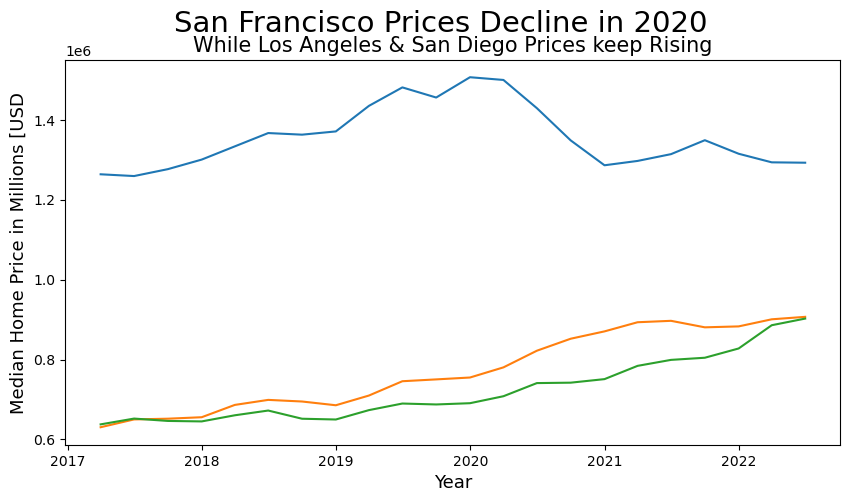

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ca_markets.index, ca_markets['San Francisco'])
ax.plot(ca_markets.index, ca_markets['Los Angeles'])
ax.plot(ca_markets.index, ca_markets['San Diego'])


fig.suptitle('San Francisco Prices Decline in 2020', fontsize=21)
ax.set_title('While Los Angeles & San Diego Prices keep Rising', fontsize=15)
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Median Home Price in Millions [USD', fontsize=13)
plt.show()

<br><br>

---

## LABORATORY

In [8]:
housing_raw = pd.read_csv('../Data/housing_data.csv', 
                          parse_dates=['period_begin', 'period_end'],
                          dtype={'total_homes_sold':'Int32'}).dropna()

display(housing_raw.head())
housing_raw.info(memory_usage='deep')

,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply
2,"Johnson County, TX",2019-09-23,2019-12-15,577,717.0,778.0,63.0,268737.6,17.095583
3,"Holmes County, OH",2017-10-09,2017-12-31,22,52.0,54.0,109.4,115308.3,34.050000
4,"Madison County, FL",2017-01-09,2017-04-02,12,54.0,55.0,151.2,158062.5,38.300000
5,"Barry County, MO",2020-11-23,2021-02-14,79,70.0,77.0,82.8,196509.1,13.157870
6,"Sacramento County, CA",2020-06-22,2020-09-13,5107,1729.0,2206.0,27.5,445540.9,5.235794


<class 'pandas.core.frame.DataFrame'>
Index: 560915 entries, 2 to 622332
Data columns (total 9 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   region_name               560915 non-null  object        
 1   period_begin              560915 non-null  datetime64[ns]
 2   period_end                560915 non-null  datetime64[ns]
 3   total_homes_sold          560915 non-null  Int32         
 4   inventory                 560915 non-null  float64       
 5   active_listings           560915 non-null  float64       
 6   age_of_inventory          560915 non-null  float64       
 7   median_active_list_price  560915 non-null  float64       
 8   months_of_supply          560915 non-null  float64       
dtypes: Int32(1), datetime64[ns](2), float64(5), object(1)
memory usage: 72.7 MB


In [9]:
# Solution No.1 
# ca_housing = housing_raw[housing_raw.region_name.str.contains('CA')].copy()
# ca_housing['region_name'] = ca_housing.region_name.str[:-11]

# Solution No.2
ca_housing = (housing_raw[housing_raw.region_name.str.endswith('CA')]
    .assign(region_name = lambda x: x.region_name.str[:-11])
    .reset_index(drop=True).astype({'region_name':'category',
                                    'inventory':'Int32',
                                    'active_listings':'Int32',
                                    'age_of_inventory':'Float32',
                                    'months_of_supply':'Float32'
                                   })
)

display(ca_housing)
ca_housing.info(memory_usage='deep')

,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply
0,Sacramento,2020-06-22,2020-09-13,5107,1729,2206,27.5,445540.9,5.235794
1,Nevada,2018-09-03,2018-11-25,529,480,517,71.400002,557508.3,12.165606
2,Stanislaus,2017-06-05,2017-08-27,1572,1042,1193,38.799999,320660.0,9.212632
3,Tehama,2020-01-20,2020-04-12,102,241,252,99.199997,297979.1,31.530228
4,Stanislaus,2017-11-13,2018-02-04,1200,797,907,56.5,330049.9,9.744362
...,...,...,...,...,...,...,...,...,...
14823,Colusa,2018-09-17,2018-12-09,30,8,8,83.0,392749.8,4.909722
14824,Merced,2018-01-08,2018-04-01,535,552,612,55.599998,291834.9,14.373568
14825,Lassen,2017-05-01,2017-07-23,1,4,4,121.099998,138666.6,5.0
14826,Los Angeles,2021-06-28,2021-09-19,19525,14252,16098,35.5,888483.3,10.00876


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14828 entries, 0 to 14827
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   region_name               14828 non-null  category      
 1   period_begin              14828 non-null  datetime64[ns]
 2   period_end                14828 non-null  datetime64[ns]
 3   total_homes_sold          14828 non-null  Int32         
 4   inventory                 14828 non-null  Int32         
 5   active_listings           14828 non-null  Int32         
 6   age_of_inventory          14828 non-null  Float32       
 7   median_active_list_price  14828 non-null  float64       
 8   months_of_supply          14828 non-null  Float32       
dtypes: Float32(2), Int32(3), category(1), datetime64[ns](2), float64(1)
memory usage: 729.2 KB


In [10]:
ca_housing_pivot = (ca_housing
    .pivot_table(index='period_begin', columns='region_name', 
                 values='median_active_list_price', aggfunc='mean',
                 observed=True)
    .assign(CA_average = lambda x: x.mean(axis=1))
)

ca_housing_pivot.head()

region_name,Alameda,Alpine,Amador,Butte,Calaveras,Colusa,Contra Costa,El Dorado,Fresno,Glenn,...,Stanislaus,Sutter,Tehama,Trinity,Tulare,Tuolumne,Ventura,Yolo,Yuba,CA_average
period_begin,,,,,,,,,,,,,,,,,,,,,
2017-01-02,730602.5,NaN,408570.6,291315.3,503458.3,339075.0,603901.2,557404.1,251850.0,237145.8,...,300302.0,257172.9,241695.8,374187.5,225395.8,493908.3,661054.7,447859.2,326833.3,498664.030000
2017-01-09,736230.0,NaN,408566.4,292348.2,517645.8,340291.6,610701.2,563658.3,253016.6,237145.8,...,301900.0,264609.3,243979.1,368312.5,227729.1,449816.6,662463.1,449942.5,336129.1,500395.862000
2017-01-16,742021.6,NaN,408483.2,293514.9,524108.3,340291.6,616534.5,565908.3,254187.5,237841.6,...,303858.3,270795.8,246266.6,363729.1,229060.4,412975.0,664828.6,453525.8,345425.0,502361.666000
2017-01-23,748271.7,NaN,408404.0,294619.1,536408.3,341958.3,621617.8,567158.3,255854.1,238041.6,...,306350.0,274861.4,248141.6,360437.5,229806.2,373483.3,666362.5,456875.8,354720.8,503231.368627
2017-01-30,753938.4,NaN,407079.0,295527.4,543704.1,344041.6,625516.2,567533.3,258000.0,238125.0,...,308191.6,279764.5,249762.5,360250.0,230139.5,333991.6,668787.5,458300.8,364016.6,505131.909804


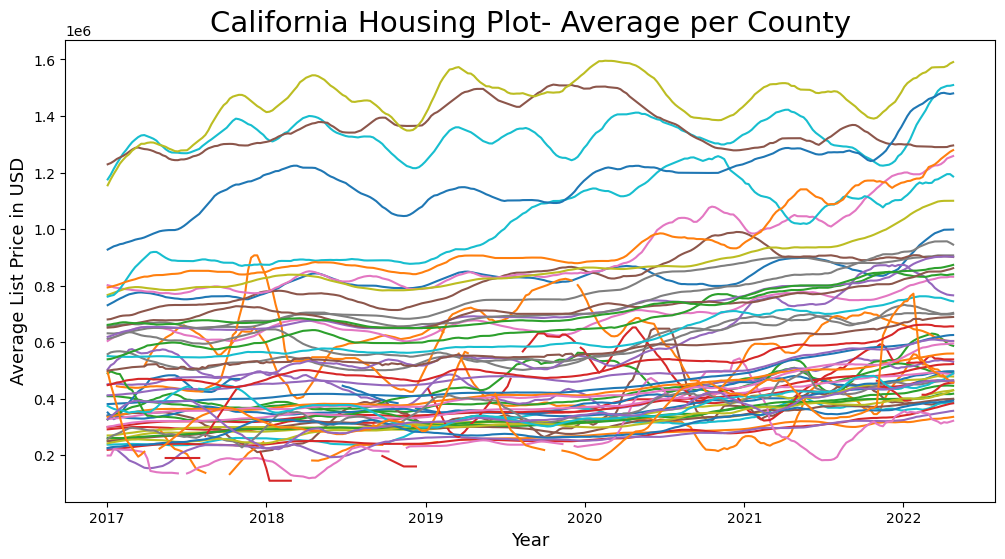

In [11]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(ca_housing_pivot.index, ca_housing_pivot)
ax.set_title('California Housing Plot- Average per County', fontsize=21)
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Average List Price in USD', fontsize=13)
plt.show()

<br><br>

>---
>Since California has a lot of Counties we need to filter by selecting only the most representative for us...
>
>---



In [12]:
ca_housing_3 = ca_housing_pivot[["San Francisco", "Los Angeles", "San Diego", "CA_average"]]
ca_housing_3.head()

region_name,San Francisco,Los Angeles,San Diego,CA_average
period_begin,,,,
2017-01-02,1229018.7,611561.0,618570.8,498664.030000
2017-01-09,1233393.7,614061.0,621737.5,500395.862000
2017-01-16,1239977.0,617311.0,625820.8,502361.666000
2017-01-23,1247977.0,620644.3,629491.6,503231.368627
2017-01-30,1253310.4,624541.6,632824.0,505131.909804


In [13]:
sns.set_style('darkgrid')

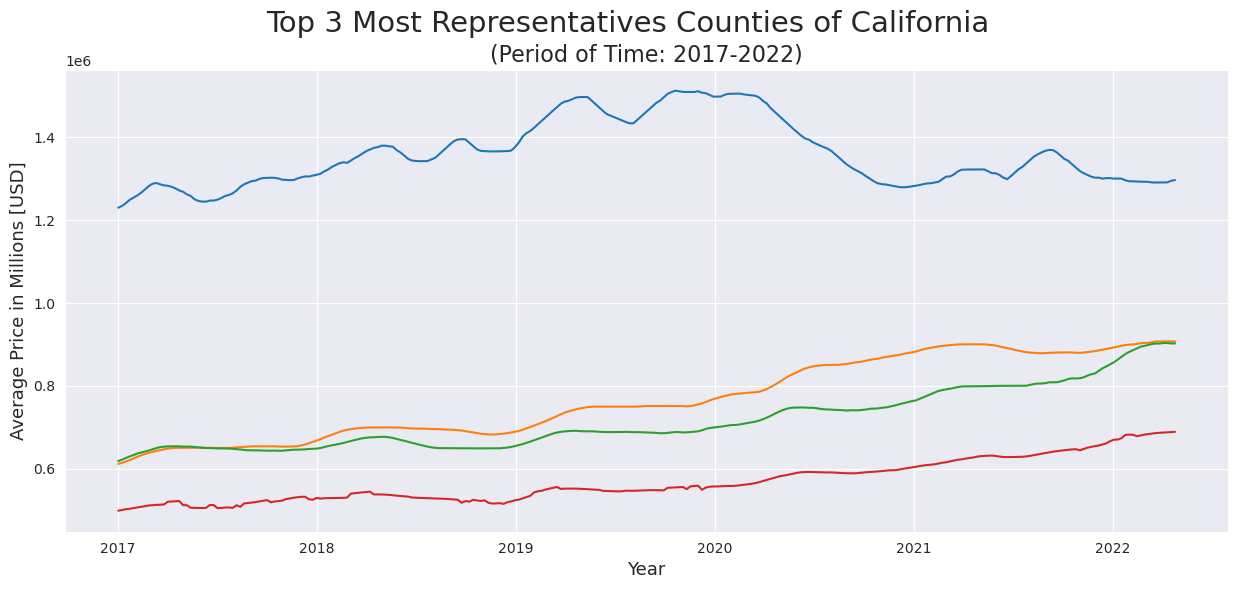

In [14]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(ca_housing_3.index, ca_housing_3['San Francisco'])
ax.plot(ca_housing_3.index, ca_housing_3['Los Angeles'])
ax.plot(ca_housing_3['San Diego'])
ax.plot(ca_housing_3['CA_average'])

fig.suptitle('Top 3 Most Representatives Counties of California', fontsize=21)
ax.set_title('(Period of Time: 2017-2022)', fontsize=16)
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Average Price in Millions [USD]', fontsize=13)
plt.show()